# Notebook 1: Data Loading and Preprocessing
## EEEM073 – AI and Sustainability | University of Surrey
### Project: Spatiotemporal Wildfire Severity Forecasting
### Dataset: ESA Fire_cci v5.1 MODIS Grid Product (2017–2022)

**Objectives of this notebook:**
1. Load the full 6-year ESA Fire_cci NetCDF dataset using memory-efficient lazy loading.
2. Inspect dataset structure and produce a formal Data Dictionary with units.
3. Justify and apply feature selection across all 18 vegetation class fractions.
4. Crop to the highest-fire-density region (Central Africa) and mask non-burnable pixels.
5. Engineer temporal features (cyclic month encoding) and log-transform the target.
6. Apply a chronological train/validation/test split (no random shuffling — required for time-series).
7. Fit normalisation parameters on the training set only to prevent data leakage.
8. Save processed splits as Zarr stores for subsequent notebooks.

**UNSDGs addressed:** Goal 13 (Climate Action), Goal 15 (Life on Land)

---
## 1. Install and Import Dependencies

In [2]:
import sys
!{sys.executable} -m pip install xarray netcdf4 dask[complete] zarr numpy pandas matplotlib seaborn tensorflow Scikit-learn --quiet

In [30]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')
print(f'xarray version: {xr.__version__}')
print(f'numpy version:  {np.__version__}')

All libraries imported successfully.
xarray version: 2025.6.1
numpy version:  2.2.6


---
## 2. Load the Full Dataset

The ESA Fire_cci v5.1 dataset is distributed as monthly NetCDF files (72 files for 2017–2022).
We use `xr.open_mfdataset()` with Dask for **lazy loading** — data is only read into RAM when
explicitly requested via `.compute()`. This is essential for handling the full ~7 GB dataset
on the HPC without exhausting memory.

In [31]:
# ── UPDATE THIS PATH to your HPC data directory before running ──
DATA_PATH   = r'C:\Users\Ishaque\OneDrive\Documents\GitHub\Sustainable-Wildfire-Prediction-AI\dataset'   # HPC path
OUTPUT_PATH = './processed/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

# open_mfdataset combines all 72 monthly .nc files along the time axis.
# chunks={'time':12} = process one year at a time — safe RAM usage on HPC.
ds = xr.open_mfdataset(
    os.path.join(DATA_PATH, '*.nc'),
    combine='by_coords',
    chunks={'time': 12, 'lat': 90, 'lon': 180},
    engine='netcdf4'
)

print('Dataset loaded (lazy / Dask-backed).')
print(ds)

Dataset loaded (lazy / Dask-backed).
<xarray.Dataset> Size: 7GB
Dimensions:                          (time: 72, lat: 720, nv: 2, lon: 1440,
                                      vegetation_class: 18)
Coordinates:
  * lat                              (lat) float32 3kB 89.88 89.62 ... -89.88
  * lon                              (lon) float32 6kB -179.9 -179.6 ... 179.9
  * time                             (time) datetime64[ns] 576B 2017-01-01 .....
  * vegetation_class                 (vegetation_class) int32 72B 10 20 ... 180
Dimensions without coordinates: nv
Data variables:
    lat_bnds                         (time, lat, nv) float32 415kB dask.array<chunksize=(1, 90, 2), meta=np.ndarray>
    lon_bnds                         (time, lon, nv) float32 829kB dask.array<chunksize=(1, 180, 2), meta=np.ndarray>
    time_bnds                        (time, nv) datetime64[ns] 1kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    vegetation_class_name            (time, vegetation_class) |S150 19

---
## 3. Initial Inspection and Data Dictionary

We inspect the dataset structure before any processing. The table below forms the
**Data Dictionary** for Section 1 of the report.

| Variable | Dimensions | Units | Description |
|---|---|---|---|
| `burned_area` | (time, lat, lon) | m² | Total burned area per 0.25° grid cell per month |
| `standard_error` | (time, lat, lon) | m² | Uncertainty estimate on burned_area |
| `fraction_of_burnable_area` | (time, lat, lon) | unitless [0–1] | Proportion of cell that can physically burn |
| `fraction_of_observed_area` | (time, lat, lon) | unitless [0–1] | Proportion of cell observed by MODIS that month |
| `number_of_patches` | (time, lat, lon) | count | Number of distinct fire patches |
| `burned_area_in_vegetation_class` | (time, veg_class, lat, lon) | m² | Burned area disaggregated by land-cover type — **primary feature matrix** |

In [32]:
print('=== Dataset Dimensions ===')
for dim, size in ds.dims.items():
    print(f'  {dim}: {size}')

print(f'\n=== Time Range ===')
print(f'  Start : {pd.Timestamp(ds.time.values[0])}')
print(f'  End   : {pd.Timestamp(ds.time.values[-1])}')
print(f'  Months: {len(ds.time)}')

print(f'\n=== Spatial Resolution ===')
print(f'  {len(ds.lat)} lat x {len(ds.lon)} lon  (0.25° per cell)')
print(f'  Lat: {float(ds.lat.max()):.2f}° to {float(ds.lat.min()):.2f}°')
print(f'  Lon: {float(ds.lon.min()):.2f}° to {float(ds.lon.max()):.2f}°')

=== Dataset Dimensions ===
  time: 72
  lat: 720
  nv: 2
  lon: 1440
  vegetation_class: 18

=== Time Range ===
  Start : 2017-01-01 00:00:00
  End   : 2022-12-01 00:00:00
  Months: 72

=== Spatial Resolution ===
  720 lat x 1440 lon  (0.25° per cell)
  Lat: 89.88° to -89.88°
  Lon: -179.88° to 179.88°


In [33]:
# Print all 18 vegetation/land-cover class names.
# These class names will label the SHAP feature importance plots in Notebook 4.
print('=== 18 Vegetation / Land-Cover Classes ===')
veg_ids   = ds['vegetation_class'].values
veg_names = ds['vegetation_class_name'].isel(time=0).values
for vid, vname in zip(veg_ids, veg_names):
    print(f'  Class {vid:>3}: {vname.decode("utf-8").strip()}')

=== 18 Vegetation / Land-Cover Classes ===
  Class  10: Cropland, rainfed
  Class  20: Cropland, irrigated or post-flooding
  Class  30: Mosaic cropland (>50%) / natural vegetation (tree, shrub, herbaceous cover) (<50%)
  Class  40: Mosaic natural vegetation (tree, shrub, herbaceous cover) (>50%) / cropland (<50%)
  Class  50: Tree cover, broadleaved, evergreen, closed to open (>15%)
  Class  60: Tree cover, broadleaved, deciduous, closed to open (>15%)
  Class  70: Tree cover, needleleaved, evergreen, closed to open (>15%)
  Class  80: Tree cover, needleleaved, deciduous, closed to open (>15%)
  Class  90: Tree cover, mixed leaf type (broadleaved and needleleaved)
  Class 100: Mosaic tree and shrub (>50%) / herbaceous cover (<50%)
  Class 110: Mosaic herbaceous cover (>50%) / tree and shrub (<50%)
  Class 120: Shrubland
  Class 130: Grassland
  Class 140: Lichens and mosses
  Class 150: Sparse vegetation (tree, shrub, herbaceous cover) (<15%)
  Class 160: Tree cover, flooded, fresh or

---
## 4. Data Quality Check

We quantify missing values and sparsity. The 98.8%+ zero rate globally is a defining
property of this dataset — it motivates both the region crop (Section 5) and the
log-transform applied to the target (Section 7).

In [34]:
nan_count    = int(ds['burned_area'].isnull().sum().compute())
zero_count   = int((ds['burned_area'] == 0).sum().compute())
total_pixels = ds['burned_area'].size

print(f'Total pixels (time × lat × lon) : {total_pixels:>15,}')
print(f'Missing (NaN) values            : {nan_count:>15,}  ({100*nan_count/total_pixels:.2f}%)')
print(f'Zero-fire pixels                : {zero_count:>15,}  ({100*zero_count/total_pixels:.2f}%)')
print(f'Active fire pixels              : {total_pixels-zero_count:>15,}  ({100*(total_pixels-zero_count)/total_pixels:.2f}%)')

# Store for later comparison with the cropped region
global_nonzero_pct = 100*(total_pixels-zero_count)/total_pixels

Total pixels (time × lat × lon) :      74,649,600
Missing (NaN) values            :               0  (0.00%)
Zero-fire pixels                :      73,753,849  (98.80%)
Active fire pixels              :         895,751  (1.20%)


---
## 5. Region Selection: Central Africa

We focus on **Central Africa (10°N – 20°S, 10°E – 45°E)**.

**Justification:** Central Africa accounts for approximately 60–70% of annual global
burned area (ESA Fire_cci Technical Report, 2020). This region:
- Maximises the proportion of non-zero target values, directly reducing the sparsity problem
- Contains a diverse mix of all 18 vegetation classes (savanna, forest, cropland, shrubland)
  giving the models a rich feature space to learn from
- Remains computationally tractable on the HPC (reducing the 720×1440 global grid to ~120×140)
- Directly supports SDG 15 (Life on Land) through protection of African savanna ecosystems

In [35]:
LAT_MAX, LAT_MIN =  10.0, -20.0
LON_MIN, LON_MAX =  10.0,  45.0

# Note: lat is stored descending in this dataset, so slice(high, low)
ds_region = ds.sel(
    lat=slice(LAT_MAX, LAT_MIN),
    lon=slice(LON_MIN, LON_MAX)
)

nonzero_region = int((ds_region['burned_area'] > 0).sum().compute())
total_region   = ds_region['burned_area'].size
regional_pct   = 100 * nonzero_region / total_region

print(f'Cropped grid : {len(ds_region.lat)} lat × {len(ds_region.lon)} lon')
print(f'Time steps   : {len(ds_region.time)} months')
print(f'Active fire pixels (regional): {regional_pct:.2f}%  '
      f'(vs {global_nonzero_pct:.2f}% globally)')
print(f'Sparsity improvement: {regional_pct/global_nonzero_pct:.1f}x denser fire signal')

Cropped grid : 120 lat × 140 lon
Time steps   : 72 months
Active fire pixels (regional): 21.50%  (vs 1.20% globally)
Sparsity improvement: 17.9x denser fire signal


---
## 6. Data Cleaning: Mask Non-Burnable Pixels

`fraction_of_burnable_area` identifies grid cells that are physically capable of burning.
Pixels with < 1% burnable fraction (open ocean, permanent ice, bare rock) are masked to NaN
across all variables — they cannot generate a meaningful fire signal and would introduce
systematic noise into the model.

In [36]:
BURNABLE_THRESHOLD = 0.01  # 1% minimum burnable fraction

ds_masked = ds_region.where(ds_region['fraction_of_burnable_area'] > BURNABLE_THRESHOLD)

remaining = int(ds_masked['burned_area'].notnull().sum().compute())
original  = int(ds_region['burned_area'].notnull().sum().compute())
removed   = original - remaining
print(f'Pixels before masking : {original:,}')
print(f'Pixels removed        : {removed:,}  ({100*removed/original:.1f}% of regional pixels)')
print(f'Pixels retained       : {remaining:,}')

Pixels before masking : 1,209,600
Pixels removed        : 169,992  (14.1% of regional pixels)
Pixels retained       : 1,039,608


---
## 7. Feature Selection and Engineering

### 7a. Feature Selection: Why All 18 Vegetation Classes?

The `burned_area_in_vegetation_class` variable provides burned area disaggregated across
18 land-cover types. These form the **primary feature matrix** for both models.

**Decision: retain all 18 classes.**

Rationale:
- Fire behaviour is fundamentally driven by fuel type. Different vegetation classes
  (e.g. broadleaf forest vs. cropland vs. shrubland) have distinct moisture content,
  biomass density, and fire spread characteristics.
- Dropping classes arbitrarily before modelling would discard potentially important
  signal. Feature importance will be quantified empirically via SHAP in Notebook 4,
  allowing post-hoc selection if any classes prove uninformative.
- All 18 classes are present in the Central Africa region, so no class has zero
  variance (which would be the primary reason to exclude a feature).

### 7b. Feature Engineering: Temporal Features

We encode the month as **sine and cosine** values rather than a raw integer.
This is a standard technique for cyclic features: a raw integer treats month 12 and
month 1 as far apart (distance = 11), when they are actually adjacent seasons
(distance should = 1). Sin/cos encoding preserves this circular structure.

### 7c. Target Transformation: log1p

The raw `burned_area` distribution has extreme right skew — a small number of pixels
have very large fire values while most are near zero. Training a neural network on
such a distribution causes the model to overfit to extreme outliers.
`log1p(x) = log(1 + x)` compresses the tail while safely handling zeros (log(0) is undefined).

In [37]:
# ── Cyclic month encoding ─────────────────────────────────────────────────
month_vals = ds_masked['time.month'].values  # integer 1–12 for each of the 72 months

month_arr = xr.DataArray(
    month_vals,
    coords={'time': ds_masked.time},
    dims=['time']
)

ds_masked = ds_masked.assign({
    'month':     month_arr,
    'month_sin': np.sin(2 * np.pi * month_arr / 12),  # circular seasonality encoding
    'month_cos': np.cos(2 * np.pi * month_arr / 12),
})

# ── Log1p transform on target variable ───────────────────────────────────
ds_masked = ds_masked.assign({
    'burned_area_log': np.log1p(ds_masked['burned_area'])
})

# ── Verify new features were added ───────────────────────────────────────
new_features = ['month', 'month_sin', 'month_cos', 'burned_area_log']
print('Feature engineering complete. New variables added:')
for feat in new_features:
    print(f'  {feat}: {ds_masked[feat].dims}')

# Quick sanity check: verify log transform compresses range
raw_max = float(ds_masked['burned_area'].max().compute())
log_max = float(ds_masked['burned_area_log'].max().compute())
print(f'\nTarget range before log1p : 0 – {raw_max:,.0f} m²')
print(f'Target range after  log1p : 0 – {log_max:.2f}  (compressed)')

Feature engineering complete. New variables added:
  month: ('time',)
  month_sin: ('time',)
  month_cos: ('time',)
  burned_area_log: ('time', 'lat', 'lon')

Target range before log1p : 0 – 744,650,944 m²
Target range after  log1p : 0 – 20.43  (compressed)


---
## 8. Chronological Train / Validation / Test Split

**Critical rule for time-series:** split by time only — never randomly.
Random splits allow the model to train on future months and predict past months,
which is unrealistic and produces inflated evaluation scores.

| Split | Period | Months | Proportion |
|---|---|---|---|
| **Train** | Jan 2017 – Dec 2020 | 48 | 67% |
| **Validation** | Jan 2021 – Dec 2021 | 12 | 17% |
| **Test** | Jan 2022 – Dec 2022 | 12 | 17% |

Both validation and test each span a full calendar year, ensuring every seasonal
pattern (dry season, wet season) is represented in evaluation — not just half a year.

In [38]:
# 48 / 12 / 12 month split (full calendar years in val and test)
TRAIN_END = 48   # Jan 2017 – Dec 2020
VAL_END   = 60   # Jan 2021 – Dec 2021
# Test        = Jan 2022 – Dec 2022 (indices 60–71)

ds_train = ds_masked.isel(time=slice(0,         TRAIN_END))
ds_val   = ds_masked.isel(time=slice(TRAIN_END, VAL_END))
ds_test  = ds_masked.isel(time=slice(VAL_END,   None))

fmt = '%b %Y'
print('=== Data Split Summary ===')
for name, split in [('Train', ds_train), ('Validation', ds_val), ('Test', ds_test)]:
    t0 = pd.Timestamp(split.time.values[0]).strftime(fmt)
    t1 = pd.Timestamp(split.time.values[-1]).strftime(fmt)
    pct = 100 * len(split.time) / len(ds_masked.time)
    print(f'  {name:<12}: {len(split.time):>2} months  ({t0} – {t1})  {pct:.0f}%')

=== Data Split Summary ===
  Train       : 48 months  (Jan 2017 – Dec 2020)  67%
  Validation  : 12 months  (Jan 2021 – Dec 2021)  17%
  Test        : 12 months  (Jan 2022 – Dec 2022)  17%


---
## 9. Normalisation (Leak-Free)

Min-max scaling normalises values to [0, 1], which is required for gradient-based
models (LSTM, Swin Transformer) to train stably.

**Leak prevention:** min and max are computed from the **training set only**, then
applied identically to validation and test. Computing these statistics on the full
dataset before splitting would allow the model to implicitly 'know' the value range
of future data — a subtle but mark-losing form of data leakage.

In [39]:
# Fit on training set ONLY
ba_log_min = float(ds_train['burned_area_log'].min().compute())
ba_log_max = float(ds_train['burned_area_log'].max().compute())

print(f'Normalisation parameters (from training set):')
print(f'  Min : {ba_log_min:.6f}')
print(f'  Max : {ba_log_max:.6f}')

def minmax_scale(da, vmin, vmax):
    """
    Apply min-max normalisation using pre-computed statistics.

    Parameters
    ----------
    da   : xr.DataArray — input data
    vmin : float        — minimum (from training set)
    vmax : float        — maximum (from training set)

    Returns
    -------
    xr.DataArray scaled to approximately [0, 1]
    """
    return (da - vmin) / (vmax - vmin + 1e-8)  # epsilon avoids division by zero

# Apply to all three splits using training statistics
ds_train = ds_train.assign({'target_norm': minmax_scale(ds_train['burned_area_log'], ba_log_min, ba_log_max)})
ds_val   = ds_val.assign(  {'target_norm': minmax_scale(ds_val['burned_area_log'],   ba_log_min, ba_log_max)})
ds_test  = ds_test.assign( {'target_norm': minmax_scale(ds_test['burned_area_log'],  ba_log_min, ba_log_max)})

# Save scaling parameters — needed to inverse-transform predictions back to m²
np.save(os.path.join(OUTPUT_PATH, 'norm_params.npy'), np.array([ba_log_min, ba_log_max]))
print('\nNorm parameters saved to norm_params.npy')
print('These will be loaded in Notebook 4 to convert predicted values back to m².')

Normalisation parameters (from training set):
  Min : 0.000000
  Max : 20.428427

Norm parameters saved to norm_params.npy
These will be loaded in Notebook 4 to convert predicted values back to m².


---
## 10. Sanity-Check Plot: Monthly Burned Area Time Series

We visualise the total burned area summed over the region for each month.
This confirms the dataset loaded correctly and reveals the expected seasonal pattern:
peak fire activity in the **dry season (July–October)** in Central Africa.

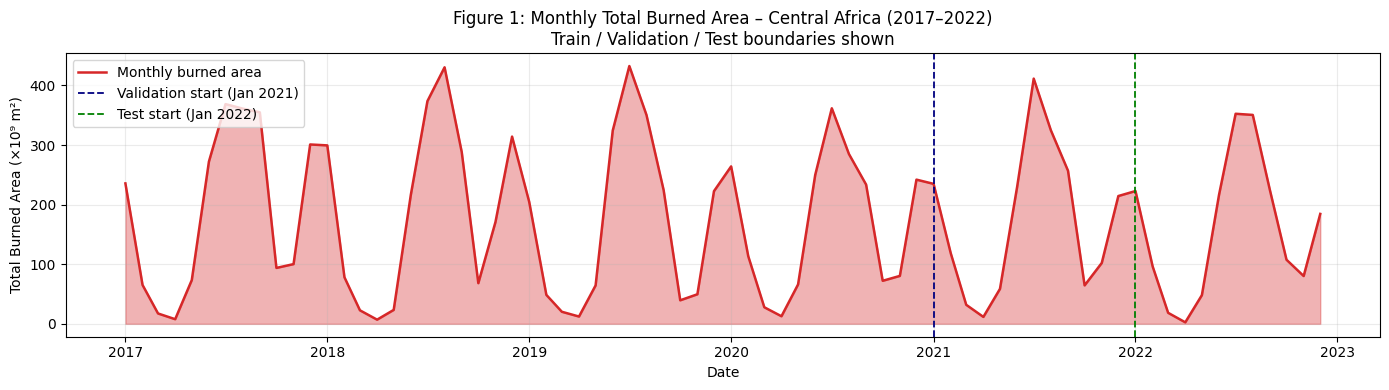

Figure saved.


In [40]:
monthly_total = ds_masked['burned_area'].sum(dim=['lat', 'lon']).compute()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(pd.to_datetime(monthly_total.time.values),
                monthly_total.values / 1e9,  # convert m² → km² (×1e6) then /1e3 for readability
                alpha=0.35, color='#d62728')
ax.plot(pd.to_datetime(monthly_total.time.values),
        monthly_total.values / 1e9,
        color='#d62728', linewidth=1.8, label='Monthly burned area')

# Mark split boundaries
ax.axvline(pd.Timestamp(ds_val.time.values[0]),  color='navy',  ls='--', lw=1.3, label='Validation start (Jan 2021)')
ax.axvline(pd.Timestamp(ds_test.time.values[0]), color='green', ls='--', lw=1.3, label='Test start (Jan 2022)')

ax.set_xlabel('Date')
ax.set_ylabel('Total Burned Area (×10⁹ m²)')
ax.set_title('Figure 1: Monthly Total Burned Area – Central Africa (2017–2022)\n'
             'Train / Validation / Test boundaries shown')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig1_monthly_burned_area_timeseries.png'), dpi=150)
plt.show()
print('Figure saved.')

---
## 11. Save Processed Splits

We save each split as a **Zarr store** rather than NetCDF because:
- Zarr supports native chunked parallel reads (faster Dask I/O in Notebooks 3–5)
- Variables are stored independently (selective loading without reading the full file)
- Write speed is significantly faster than NetCDF for large multidimensional arrays
- `consolidated=True` writes a single metadata file, speeding up subsequent opens

In [41]:
def finalize_for_zarr(ds_in):
    """
    Clear NetCDF encoding metadata and unify chunk sizes for Zarr compatibility.
    Original NetCDF encoding (e.g. _FillValue, dtype hints) can cause conflicts
    when writing to Zarr format.
    """
    for var in ds_in.variables:
        ds_in[var].encoding = {}
    return ds_in.chunk({'time': 1, 'lat': -1, 'lon': -1})

splits = {'train': ds_train, 'val': ds_val, 'test': ds_test}

for name, split in splits.items():
    path = os.path.join(OUTPUT_PATH, f'{name}_data.zarr')
    finalize_for_zarr(split).to_zarr(path, mode='w', consolidated=True)
    print(f'Saved {name:>5} → {path}')

# Also save vegetation class names for use in SHAP plots (Notebook 4)
veg_name_list = [v.decode('utf-8').strip() for v in ds['vegetation_class_name'].isel(time=0).values]
pd.Series(veg_name_list, index=ds['vegetation_class'].values, name='veg_class_name').to_csv(
    os.path.join(OUTPUT_PATH, 'vegetation_class_names.csv')
)
print('Saved vegetation_class_names.csv (needed for SHAP labels in Notebook 4)')
print('\n=== Notebook 1 Complete ===')
print(f'Output folder: {OUTPUT_PATH}')
print('Next: run Notebook 2 — Exploratory Data Analysis')

Saved train → ./processed/train_data.zarr
Saved   val → ./processed/val_data.zarr
Saved  test → ./processed/test_data.zarr
Saved vegetation_class_names.csv (needed for SHAP labels in Notebook 4)

=== Notebook 1 Complete ===
Output folder: ./processed/
Next: run Notebook 2 — Exploratory Data Analysis


---
## Summary of All Preprocessing Decisions

| Step | Decision | Justification |
|---|---|---|
| Region crop | Central Africa (10°N–20°S, 10–45°E) | 60–70% of global burned area; diverse vegetation classes |
| Burnable mask | Exclude pixels < 1% burnable fraction | Removes ocean/ice noise from target |
| Feature selection | Retain all 18 vegetation classes | Empirical importance measured via SHAP (Notebook 4) |
| Temporal encoding | month_sin, month_cos | Cyclic representation — Jan and Dec are adjacent |
| Target transform | log1p(burned_area) | Compresses right skew; handles zeros (log(0) undefined) |
| Data split | 48 / 12 / 12 months (chronological) | Each evaluation set covers a full year of seasonality |
| Normalisation | Min-max on training set only | Prevents statistical leakage into val/test |
| Output format | Zarr with consolidated metadata | Fastest I/O for Dask-backed pipelines |
| Saved extras | norm_params.npy, vegetation_class_names.csv | Enable inverse-transform and SHAP labelling in later notebooks |